In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score

In [65]:
MODEL_START_SEASON = 2010
VALIDATION_SEASON = 2024
TEST_SEASON = 2025
RANDOM_STATE = 42

In [66]:
df = pd.read_csv('../data/processed/model_dataset_v2.csv', parse_dates=['gameday'],)

In [67]:
df = (
    df
    .sort_values(['gameday', 'game_id'])
    .reset_index(drop=True)
)
df.shape

(4617, 80)

In [68]:
feature_columns = [
    'pregame_off_epa_blended',
    'pregame_off_success_rate_blended',
    'pregame_pass_epa_blended',
    'pregame_rush_epa_blended',
    'pregame_def_epa_allowed_blended',
    'pregame_def_success_rate_allowed_blended',
    'off_epa_last3',
    'off_success_rate_last3',
    'pass_epa_last3',
    'rush_epa_last3',
    'def_epa_allowed_last3',
    'def_success_rate_allowed_last3',
    'off_epa_last5',
    'off_success_rate_last5',
    'pass_epa_last5',
    'rush_epa_last5',
    'def_epa_allowed_last5',
    'def_success_rate_allowed_last5',
    'off_epa_ewm',
    'off_success_rate_ewm',
    'pass_epa_ewm',
    'rush_epa_ewm',
    'def_epa_allowed_ewm',
    'def_success_rate_allowed_ewm',
    'pregame_elo',
    'pregame_sos',
    'rest_days',
    'short_rest',
    'prior_games',
    'pregame_turnovers',
    'pregame_takeaways',
    'pregame_off_sack_rate',
    'pregame_def_sack_rate',
    'pregame_qb_epa',
    'pregame_qb_epa_last5',
    'pregame_qb_success_rate'
]

features = [
    f"{side}_{column}"
    for side in ["home", "away"]
    for column in feature_columns
] + ["neutral_site"]

target = 'home_win'

In [69]:
train = df[df['season'].between(MODEL_START_SEASON, 2023)].copy()
val = df[df['season'] == VALIDATION_SEASON].copy()
test = df[df['season'] == TEST_SEASON].copy()

X_train = train[features]
y_train = train[target]

X_val = val[features]
y_val = val[target]

X_test = test[features]
y_test = test[target]

print('Training Games:', len(train))
print('Validation Games:', len(val))
print('Test Games:', len(test))

Training Games: 3781
Validation Games: 285
Test Games: 284


In [70]:
def evaluate_probabilities(
        model_name,
        y_true,
        probabilities,
        evaluation_period=None,
):
    predictions = (probabilities >= 0.5).astype(int)

    return {
        'model': model_name,
        'period': evaluation_period,
        'accuracy': accuracy_score(y_true, predictions),
        'log_loss': log_loss(y_true, probabilities),
        'brier_score': brier_score_loss(y_true, probabilities),
        'roc_auc': roc_auc_score(y_true, probabilities),
        }

In [71]:
training_home_win_rate = y_train.mean()

baseline_val_prob = np.full(
    len(y_val),
    training_home_win_rate,
)

baseline_result = evaluate_probabilities(
    model_name='Baseline',
    y_true=y_val,
    probabilities=baseline_val_prob,
    evaluation_period='2024',
)

pd.DataFrame([baseline_result]).head()

,model,period,accuracy,log_loss,brier_score,roc_auc
0,Baseline,2024,0.547368,0.688958,0.247907,0.5


In [72]:
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

In [73]:
random_forest_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

In [74]:
gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=20,
    l2_regularization=1,
    early_stopping=False,
    random_state=RANDOM_STATE,
)

In [75]:
initial_models = {
    "Logistic Regression V2": logistic_model,
    "Random Forest": random_forest_model,
    "Histogram Gradient Boosting": gradient_boosting_model,
}

fitted_initial_models = {}
validation_probabilities = {}
validation_rows = [baseline_result]

for model_name, estimator in initial_models.items():
    fitted_model = clone(estimator)
    fitted_model.fit(X_train, y_train)

    probabilities = fitted_model.predict_proba(X_val)[:, 1]

    fitted_initial_models[model_name] = fitted_model
    validation_probabilities[model_name] = probabilities

    validation_rows.append(
        evaluate_probabilities(
            model_name=model_name,
            y_true=y_val,
            probabilities=probabilities,
            evaluation_period='2024',
        )
    )

In [76]:
initial_results = (
    pd.DataFrame(validation_rows)  
    .sort_values(['log_loss', 'brier_score'], ascending=True)
    .reset_index(drop=True)
)

initial_results


,model,period,accuracy,log_loss,brier_score,roc_auc
0,Random Forest,2024,0.677193,0.612427,0.211144,0.733502
1,Logistic Regression V2,2024,0.652632,0.622125,0.216819,0.709253
2,Histogram Gradient Boosting,2024,0.652632,0.634156,0.220978,0.698022
3,Baseline,2024,0.547368,0.688958,0.247907,0.500000


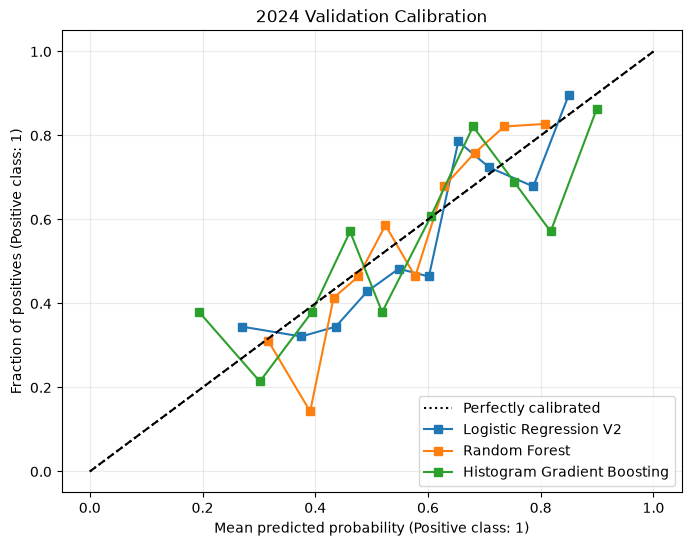

In [77]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probabilities in validation_probabilities.items():
    CalibrationDisplay.from_predictions(
        y_val,
        probabilities,
        n_bins=10,
        strategy='quantile',
        name=model_name,
        ax=ax,
    )
ax.plot(
    [0, 1], [0, 1],
    linestyle='--',
    color='black',
    label='Perfect calibration'
)

ax.set_title('2024 Validation Calibration')
ax.grid(alpha=0.25)
plt.show()

In [78]:
v1_df = pd.read_csv('../data/processed/model_dataset_v1.csv')
v1_artifact = joblib.load('../models/logistic_regression_v1.joblib')

v1_features = v1_artifact['features']
v1_model = v1_artifact['model']

v1_val = v1_df[v1_df['season'] == 2024].copy()

common_game_ids = sorted(
    set(v1_val['game_id'])
    & set(val['game_id'])
)

v1_common = (v1_val[v1_val['game_id'].isin(common_game_ids)]
            .sort_values('game_id'))
v2_common = (val[val['game_id'].isin(common_game_ids)]
            .sort_values('game_id'))


In [79]:
v1_common_prob = v1_model.predict_proba(v1_common[v1_features])[:, 1]

v2_common_prob = fitted_initial_models[
    'Logistic Regression V2'
    ].predict_proba(v2_common[features])[:, 1]

In [80]:
v1_v2_results = pd.DataFrame([
    evaluate_probabilities(
        'Logistic Regression V1',
        v1_common['home_win'],
        v1_common_prob,
        '2024 shared games',
    ),
    evaluate_probabilities(
        'Logistic Regression V2',
        v2_common['home_win'],
        v2_common_prob,
        '2024 shared games',
    ),
])

v1_v2_results



,model,period,accuracy,log_loss,brier_score,roc_auc
0,Logistic Regression V1,2024 shared games,0.672862,0.622797,0.215553,0.727642
1,Logistic Regression V2,2024 shared games,0.654275,0.623086,0.217162,0.709455


In [81]:
development = df[df['season'].between(MODEL_START_SEASON, 2024)].copy()

CV_SEASONS = [2020, 2021, 2022, 2023, 2024]